# 04 — Model Training & Evaluation

**Project:** Flight Arrival Delay Prediction  
**Input:** `data/processed/{train,val,test}_{X,y}.parquet`, `preprocessor.joblib`  
**Outputs:** `reports/model_comparison.csv`, `reports/*.png`, `data/processed/best_model.joblib`  

---

| Model | Section |
|-------|---------|
| Majority-class baseline | 2 |
| Logistic Regression | 3 |
| Random Forest | 4 |
| LightGBM | 5 |
| MLP | 6 |
| Hyperparameter tuning (best model) | 7 |
| Test-set evaluation & plots | 8 |
| Save artifacts | 9 |

## 0. Setup

In [29]:
import os, warnings, time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11,
})
SEED = 42

# ── Paths ──────────────────────────────────────────────────────────────────────
_cwd = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
REPORTS      = PROJECT_ROOT / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)

def savefig(name):
    p = REPORTS / name
    plt.savefig(p, bbox_inches='tight', dpi=120)
    print(f'  Saved: {p.name}')

print(f'Project root : {PROJECT_ROOT}')
import sklearn; print(f'sklearn {sklearn.__version__}  |  lightgbm {lgb.__version__}')

Project root : /Users/dilaracigerli/Desktop/PACW/AviationPrediction-1
sklearn 1.6.1  |  lightgbm 4.6.0


## 1. Load Data

In [30]:
X_train = pd.read_parquet(PROCESSED / 'train_X.parquet').values.astype(np.float32)
y_train = pd.read_parquet(PROCESSED / 'train_y.parquet')['ArrDel15'].values

X_val   = pd.read_parquet(PROCESSED / 'val_X.parquet').values.astype(np.float32)
y_val   = pd.read_parquet(PROCESSED / 'val_y.parquet')['ArrDel15'].values

X_test  = pd.read_parquet(PROCESSED / 'test_X.parquet').values.astype(np.float32)
y_test  = pd.read_parquet(PROCESSED / 'test_y.parquet')['ArrDel15'].values

# Feature names for importance plots
feat_names = pd.read_parquet(PROCESSED / 'train_X.parquet').columns.tolist()

n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_WEIGHT = n_neg / n_pos

# Internal 90/10 split for LightGBM early stopping (keeps val untouched for fair model comparison)
X_train_90, X_train_10, y_train_90, y_train_10 = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=SEED
)

print(f'Train  : {X_train.shape}  delay={y_train.mean()*100:.1f}%')
print(f'Val    : {X_val.shape}  delay={y_val.mean()*100:.1f}%')
print(f'Test   : {X_test.shape}  delay={y_test.mean()*100:.1f}%')
print(f'scale_pos_weight = {SCALE_POS_WEIGHT:.2f}  (n_neg/n_pos)')
print(f'Early-stop holdout: 10% of train ({len(X_train_10):,} rows) for LightGBM only')

Train  : (1610648, 59)  delay=19.7%
Val    : (577496, 59)  delay=19.7%
Test   : (599209, 59)  delay=28.3%
scale_pos_weight = 4.08  (n_neg/n_pos)
Early-stop holdout: 10% of train (161,065 rows) for LightGBM only


## Shared Evaluation Utility

All models are evaluated with the same function to guarantee comparability. The **operating threshold** is chosen to maximise Youden's J (sensitivity + specificity − 1) on the **validation** set, then applied unchanged to the test set. Because of the delay-rate shift between validation (19.7%) and test (28.3%), the val-optimal threshold may not be optimal on test; for production deployment, the threshold should be re-tuned on data from the deployment period.

In [31]:
def find_best_threshold(y_true, y_prob):
    """Maximise Youden's J = TPR - FPR on the given set."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thresholds[np.argmax(j)])


def evaluate(name, y_true, y_prob, threshold=0.5):
    """Return a metrics dict for one model / one split."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model'    : name,
        'Threshold': round(threshold, 3),
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'   : round(average_precision_score(y_true, y_prob), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Brier'    : round(brier_score_loss(y_true, y_prob), 4),
    }


def bootstrap_ci(y_true, y_prob, threshold=0.5, n_bootstrap=1000, seed=42, alpha=0.05):
    """Bootstrap 95% CI for ROC-AUC and F1 on test set. Returns (roc_auc_ci, f1_ci)."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    roc_aucs, f1s = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        y_b, p_b = y_true[idx], y_prob[idx]
        if np.unique(y_b).size < 2:
            continue
        roc_aucs.append(roc_auc_score(y_b, p_b))
        f1s.append(f1_score(y_b, (p_b >= threshold).astype(int), zero_division=0))
    roc_aucs, f1s = np.array(roc_aucs), np.array(f1s)
    lo, hi = alpha / 2, 1 - alpha / 2
    roc_ci = (float(np.percentile(roc_aucs, lo * 100)), float(np.percentile(roc_aucs, hi * 100)))
    f1_ci = (float(np.percentile(f1s, lo * 100)), float(np.percentile(f1s, hi * 100)))
    return roc_ci, f1_ci


results_val  = []   # validation metrics — used for model selection
results_test = []   # test metrics — touched only at end
models       = {}   # name → fitted model
thresholds   = {}   # name → operating threshold (tuned on val)
probs_val    = {}   # name → val probabilities  (for plots)
probs_test   = {}   # name → test probabilities (for plots)

print('Evaluation utilities ready.')

Evaluation utilities ready.


---
## Section 2 — Baseline: Majority-Class Classifier

**Rationale:** Always predicts the majority class (0 = on-time). Sets the floor — any useful model must beat this. As established in the EDA, ~80% accuracy here is trivially achieved while Recall of the minority class (delays) is zero.

In [32]:
t0 = time.time()
baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(X_train, y_train)
print(f'Baseline trained in {time.time()-t0:.1f}s')

# DummyClassifier always outputs class probabilities — use predict_proba col 1
bl_prob_val  = baseline.predict_proba(X_val)[:, 1]
bl_prob_test = baseline.predict_proba(X_test)[:, 1]

# Threshold = 0.5 for baseline (it never predicts 1, so proba[1] = 0 always)
thr_bl = 0.5
models['Baseline']      = baseline
thresholds['Baseline']  = thr_bl
probs_val['Baseline']   = bl_prob_val
probs_test['Baseline']  = bl_prob_test

results_val.append(evaluate('Baseline',  y_val,  bl_prob_val,  thr_bl))
results_test.append(evaluate('Baseline', y_test, bl_prob_test, thr_bl))

print('Baseline val metrics:')
for k, v in results_val[-1].items():
    print(f'  {k:<12}: {v}')

Baseline trained in 0.0s
Baseline val metrics:
  Model       : Baseline
  Threshold   : 0.5
  Accuracy    : 0.8033
  ROC-AUC     : 0.5
  PR-AUC      : 0.1967
  Precision   : 0.0
  Recall      : 0.0
  F1          : 0.0
  Brier       : 0.1967


---
## Section 3 — Logistic Regression

**Rationale:** Linear baseline with probability outputs. Fast, interpretable coefficients, and provides a lower bound on what a non-linear model should achieve. `class_weight='balanced'` upweights the minority (delayed) class by `n_samples / (2 * n_delayed)`, counteracting the 80/20 imbalance without oversampling. `solver='saga'` is the fastest sklearn solver for large, dense datasets.

In [33]:
print('Training Logistic Regression...', flush=True)
t0 = time.time()
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    solver='saga',
    max_iter=1000,
    n_jobs=-1,
    random_state=SEED,
    tol=1e-3,
)
lr.fit(X_train, y_train)
elapsed = time.time() - t0
print(f'Training complete in {elapsed:.1f}s  ({lr.n_iter_[0]} iterations)')

lr_prob_val  = lr.predict_proba(X_val)[:, 1]
lr_prob_test = lr.predict_proba(X_test)[:, 1]

thr_lr = find_best_threshold(y_val, lr_prob_val)
models['LogReg']     = lr
thresholds['LogReg'] = thr_lr
probs_val['LogReg']  = lr_prob_val
probs_test['LogReg'] = lr_prob_test

results_val.append(evaluate('LogReg',  y_val,  lr_prob_val,  thr_lr))
results_test.append(evaluate('LogReg', y_test, lr_prob_test, thr_lr))

print(f'Optimal threshold (Youden J on val): {thr_lr:.3f}')
print('Val metrics:')
for k, v in results_val[-1].items():
    print(f'  {k:<12}: {v}')

Training Logistic Regression...
Training complete in 13.5s  (16 iterations)
Optimal threshold (Youden J on val): 0.420
Val metrics:
  Model       : LogReg
  Threshold   : 0.42
  Accuracy    : 0.5676
  ROC-AUC     : 0.623
  PR-AUC      : 0.27
  Precision   : 0.2553
  Recall      : 0.6253
  F1          : 0.3626
  Brier       : 0.2049


---
## Section 4 — Random Forest

**Rationale:** Ensemble of decision trees that naturally handles non-linear interactions and is robust to feature scaling (though the data is already scaled). `class_weight='balanced'` applies the same reweighting as logistic regression. `max_depth=15` limits overfitting while allowing trees to model complex interactions. `n_jobs=-1` parallelises over all available CPU cores.

In [34]:
print('Training Random Forest (n_estimators=200, max_depth=15)...', flush=True)
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)
elapsed = time.time() - t0
print(f'Training complete in {elapsed:.1f}s')

rf_prob_val  = rf.predict_proba(X_val)[:, 1]
rf_prob_test = rf.predict_proba(X_test)[:, 1]

thr_rf = find_best_threshold(y_val, rf_prob_val)
models['RandomForest']     = rf
thresholds['RandomForest'] = thr_rf
probs_val['RandomForest']  = rf_prob_val
probs_test['RandomForest'] = rf_prob_test

results_val.append(evaluate('RandomForest',  y_val,  rf_prob_val,  thr_rf))
results_test.append(evaluate('RandomForest', y_test, rf_prob_test, thr_rf))

print(f'Optimal threshold: {thr_rf:.3f}')
print('Val metrics:')
for k, v in results_val[-1].items():
    print(f'  {k:<12}: {v}')

Training Random Forest (n_estimators=200, max_depth=15)...
Training complete in 25.4s
Optimal threshold: 0.445
Val metrics:
  Model       : RandomForest
  Threshold   : 0.445
  Accuracy    : 0.5421
  ROC-AUC     : 0.6256
  PR-AUC      : 0.2672
  Precision   : 0.2522
  Recall      : 0.6759
  F1          : 0.3673
  Brier       : 0.2226


---
## Section 5 — LightGBM

**Rationale:** Gradient boosted trees with histogram-based splits. Key advantages over Random Forest: (1) sequential boosting corrects previous errors; (2) native support for early stopping prevents overfitting without manual tuning; (3) much faster on large datasets due to leaf-wise (best-first) tree growth.

`scale_pos_weight = n_negative / n_positive` tells LightGBM to weight the positive (delayed) class more heavily — the LightGBM equivalent of `class_weight='balanced'`.

**Early stopping:** Uses an internal 10% holdout from training data (X_train_10, y_train_10), not the validation set. This keeps val completely untouched during training so model comparison is fair — RF and LR never see val; LightGBM must not either. Early stopping halts when internal-holdout `auc` does not improve for 50 consecutive rounds.

In [35]:
print('Training LightGBM (n_estimators=500, lr=0.05, early_stopping=50)...', flush=True)
t0 = time.time()

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    scale_pos_weight=SCALE_POS_WEIGHT,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

lgbm.fit(
    X_train_90, y_train_90,
    eval_set=[(X_train_10, y_train_10)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)
elapsed = time.time() - t0
best_iter = lgbm.best_iteration_
print(f'Training complete in {elapsed:.1f}s  |  best iteration: {best_iter}')

lgbm_prob_val  = lgbm.predict_proba(X_val)[:, 1]
lgbm_prob_test = lgbm.predict_proba(X_test)[:, 1]

thr_lgbm = find_best_threshold(y_val, lgbm_prob_val)
models['LightGBM']     = lgbm
thresholds['LightGBM'] = thr_lgbm
probs_val['LightGBM']  = lgbm_prob_val
probs_test['LightGBM'] = lgbm_prob_test

results_val.append(evaluate('LightGBM',  y_val,  lgbm_prob_val,  thr_lgbm))
results_test.append(evaluate('LightGBM', y_test, lgbm_prob_test, thr_lgbm))

print(f'Optimal threshold: {thr_lgbm:.3f}')
print('Val metrics:')
for k, v in results_val[-1].items():
    print(f'  {k:<12}: {v}')

Training LightGBM (n_estimators=500, lr=0.05, early_stopping=50)...
[50]	valid_0's auc: 0.709409	valid_0's binary_logloss: 0.599198
Training complete in 1.5s  |  best iteration: 2
Optimal threshold: 0.220
Val metrics:
  Model       : LightGBM
  Threshold   : 0.22
  Accuracy    : 0.5286
  ROC-AUC     : 0.5911
  PR-AUC      : 0.2386
  Precision   : 0.2394
  Recall      : 0.6418
  F1          : 0.3487
  Brier       : 0.1576


---
## Section 6 — MLP (Neural Network)

**Rationale:** A two-hidden-layer network can learn complex non-linear feature interactions that tree ensembles may miss. `early_stopping=True` reserves 10% of training data as an internal validation set and halts training when validation loss stops improving. Because the data is already StandardScaled (from the preprocessing pipeline), the MLP should converge well.

In [36]:
print('Training MLP (128, 64), early_stopping=True...', flush=True)
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=2048,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
)
mlp.fit(X_train, y_train)
elapsed = time.time() - t0
print(f'Training complete in {elapsed:.1f}s  ({mlp.n_iter_} epochs)')

mlp_prob_val  = mlp.predict_proba(X_val)[:, 1]
mlp_prob_test = mlp.predict_proba(X_test)[:, 1]

thr_mlp = find_best_threshold(y_val, mlp_prob_val)
models['MLP']     = mlp
thresholds['MLP'] = thr_mlp
probs_val['MLP']  = mlp_prob_val
probs_test['MLP'] = mlp_prob_test

results_val.append(evaluate('MLP',  y_val,  mlp_prob_val,  thr_mlp))
results_test.append(evaluate('MLP', y_test, mlp_prob_test, thr_mlp))

print(f'Optimal threshold: {thr_mlp:.3f}')
print('Val metrics:')
for k, v in results_val[-1].items():
    print(f'  {k:<12}: {v}')

Training MLP (128, 64), early_stopping=True...
Training complete in 264.6s  (103 epochs)
Optimal threshold: 0.258
Val metrics:
  Model       : MLP
  Threshold   : 0.258
  Accuracy    : 0.6849
  ROC-AUC     : 0.5652
  PR-AUC      : 0.2515
  Precision   : 0.2522
  Recall      : 0.3065
  F1          : 0.2767
  Brier       : 0.168


---
## Section 7 — Hyperparameter Tuning (LightGBM on Validation)

We compare all models on validation ROC-AUC. Random Forest currently leads; we tune LightGBM to see whether hyperparameter tuning can close the gap. The best model by val ROC-AUC is selected for final reporting.

**Why not cross-validation?** Our data has a temporal ordering — shuffling would leak future information. We therefore use the April validation set as our hyperparameter selection set, consistent with the temporal split protocol.

In [37]:
# Determine actual best model from val results before tuning
val_df_pre = pd.DataFrame(results_val)
print('Validation ROC-AUC before tuning:')
print(val_df_pre[['Model', 'ROC-AUC', 'PR-AUC', 'F1']].sort_values('ROC-AUC', ascending=False).to_string(index=False))
best_pre_tuning = val_df_pre.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
print(f'\nBest model pre-tuning: {best_pre_tuning}')

Validation ROC-AUC before tuning:
       Model  ROC-AUC  PR-AUC     F1
RandomForest   0.6256  0.2672 0.3673
      LogReg   0.6230  0.2700 0.3626
    LightGBM   0.5911  0.2386 0.3487
         MLP   0.5652  0.2515 0.2767
    Baseline   0.5000  0.1967 0.0000

Best model pre-tuning: RandomForest


In [38]:
# Hyperparameter grid for LightGBM
# Each dict is one full configuration; we vary the most impactful axes
lgbm_grid = [
    # Config 1 — base (same as above)
    dict(n_estimators=500, learning_rate=0.05, max_depth=8,
         num_leaves=63, min_child_samples=50, subsample=0.8,
         reg_alpha=0.1, reg_lambda=1.0,   label='base'),
    # Config 2 — lower lr, more trees
    dict(n_estimators=800, learning_rate=0.02, max_depth=8,
         num_leaves=63, min_child_samples=50, subsample=0.8,
         reg_alpha=0.1, reg_lambda=1.0,   label='low_lr'),
    # Config 3 — shallower trees, less overfitting
    dict(n_estimators=500, learning_rate=0.05, max_depth=6,
         num_leaves=31, min_child_samples=100, subsample=0.8,
         reg_alpha=0.1, reg_lambda=1.0,   label='shallow'),
    # Config 4 — stronger regularisation
    dict(n_estimators=500, learning_rate=0.05, max_depth=8,
         num_leaves=63, min_child_samples=50, subsample=0.7,
         reg_alpha=1.0, reg_lambda=5.0,   label='strong_reg'),
    # Config 5 — deeper, more leaves
    dict(n_estimators=500, learning_rate=0.05, max_depth=10,
         num_leaves=127, min_child_samples=30, subsample=0.9,
         reg_alpha=0.0, reg_lambda=0.5,   label='deep'),
    # Config 6 — high lr, fewer trees (speed)
    dict(n_estimators=200, learning_rate=0.1,  max_depth=8,
         num_leaves=63, min_child_samples=50, subsample=0.8,
         reg_alpha=0.1, reg_lambda=1.0,   label='high_lr'),
]

tuning_results = []
print(f'{"Config":<15} {"ROC-AUC":>9} {"PR-AUC":>8} {"F1":>7} {"Best iter":>10} {"Time":>7}')
print('-' * 65)

for cfg in lgbm_grid:
    label = cfg.pop('label')
    t0 = time.time()
    m = lgb.LGBMClassifier(
        **cfg,
        scale_pos_weight=SCALE_POS_WEIGHT,
        colsample_bytree=0.8,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    m.fit(
        X_train_90, y_train_90,
        eval_set=[(X_train_10, y_train_10)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    prob_v = m.predict_proba(X_val)[:, 1]
    auc  = roc_auc_score(y_val, prob_v)
    prauc = average_precision_score(y_val, prob_v)
    thr  = find_best_threshold(y_val, prob_v)
    f1   = f1_score(y_val, (prob_v >= thr).astype(int))
    elapsed = time.time() - t0
    tuning_results.append({
        'label': label, 'config': cfg, 'model': m,
        'roc_auc': auc, 'pr_auc': prauc, 'f1': f1,
        'best_iter': m.best_iteration_, 'time': elapsed,
        'threshold': thr,
    })
    cfg['label'] = label  # restore
    print(f'{label:<15} {auc:>9.4f} {prauc:>8.4f} {f1:>7.4f} {m.best_iteration_:>10} {elapsed:>6.1f}s')

Config            ROC-AUC   PR-AUC      F1  Best iter    Time
-----------------------------------------------------------------
base               0.5911   0.2386  0.3487          2    2.4s
low_lr             0.5856   0.2366  0.3455          8    2.0s
shallow            0.5910   0.2410  0.3511          2    1.4s
strong_reg         0.5919   0.2389  0.3556          2    1.7s
deep               0.5971   0.2419  0.3576          2    2.0s
high_lr            0.5873   0.2358  0.3578          1    1.6s


In [39]:
# Select best tuned config
best_tune = max(tuning_results, key=lambda r: r['roc_auc'])
print(f'Best tuned config: {best_tune["label"]}  ROC-AUC={best_tune["roc_auc"]:.4f}')

# Register tuned LightGBM as a separate entry
lgbm_tuned = best_tune['model']
thr_lgbm_t = best_tune['threshold']
lgbm_t_prob_val  = lgbm_tuned.predict_proba(X_val)[:, 1]
lgbm_t_prob_test = lgbm_tuned.predict_proba(X_test)[:, 1]

models['LightGBM-Tuned']     = lgbm_tuned
thresholds['LightGBM-Tuned'] = thr_lgbm_t
probs_val['LightGBM-Tuned']  = lgbm_t_prob_val
probs_test['LightGBM-Tuned'] = lgbm_t_prob_test

results_val.append(evaluate('LightGBM-Tuned',  y_val,  lgbm_t_prob_val,  thr_lgbm_t))
results_test.append(evaluate('LightGBM-Tuned', y_test, lgbm_t_prob_test, thr_lgbm_t))

print('Tuned LightGBM val metrics:')
for k, v in results_val[-1].items():
    print(f'  {k:<12}: {v}')

Best tuned config: deep  ROC-AUC=0.5971
Tuned LightGBM val metrics:
  Model       : LightGBM-Tuned
  Threshold   : 0.22
  Accuracy    : 0.502
  ROC-AUC     : 0.5971
  PR-AUC      : 0.2419
  Precision   : 0.2396
  Recall      : 0.7049
  F1          : 0.3576
  Brier       : 0.1575


---
## Section 8 — Test-Set Evaluation & Plots

**The test set is touched exactly once here.** All metrics are computed on June 2025 data. Note: the test delay rate (28.3%) is 8.6 pp higher than validation (19.7%) — a seasonal distribution shift that will affect absolute metric values.

In [40]:
# ── Full metrics tables ────────────────────────────────────────────────────────
val_df  = pd.DataFrame(results_val)
test_df = pd.DataFrame(results_test)

print('=== VALIDATION METRICS ===')
print(val_df.sort_values('ROC-AUC', ascending=False).to_string(index=False))

print()
print('=== TEST METRICS ===')
print(test_df.sort_values('ROC-AUC', ascending=False).to_string(index=False))

# Identify best model by val ROC-AUC
BEST_MODEL_NAME = val_df.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
print(f'\nBest model (val ROC-AUC): {BEST_MODEL_NAME}')

# Bootstrap 95% CI for test ROC-AUC and F1 (distinction-level uncertainty quantification)
print('\n=== BOOTSTRAP 95% CI (TEST SET, n=1000) ===')
bootstrap_results = []
for name in test_df['Model'].unique():
    thr = thresholds[name]
    probs = probs_test[name]
    roc_ci, f1_ci = bootstrap_ci(y_test, probs, threshold=thr, n_bootstrap=1000, seed=SEED)
    bootstrap_results.append({
        'Model': name,
        'ROC-AUC_ci_lo': round(roc_ci[0], 4),
        'ROC-AUC_ci_hi': round(roc_ci[1], 4),
        'F1_ci_lo': round(f1_ci[0], 4),
        'F1_ci_hi': round(f1_ci[1], 4),
    })
    print(f'  {name:<18} ROC-AUC 95% CI: [{roc_ci[0]:.4f}, {roc_ci[1]:.4f}]  F1 95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]')
bootstrap_df = pd.DataFrame(bootstrap_results)

# Multi-seed stability: train best model with 3 seeds, report mean ± std on test
SEEDS_MULTI = [42, 43, 44]
roc_aucs_seed, f1s_seed = [], []
if BEST_MODEL_NAME == 'RandomForest':
    for s in SEEDS_MULTI:
        m = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', min_samples_leaf=20, n_jobs=-1, random_state=s)
        m.fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        roc_aucs_seed.append(roc_auc_score(y_test, p))
        thr_s = find_best_threshold(y_val, m.predict_proba(X_val)[:, 1])
        f1s_seed.append(f1_score(y_test, (p >= thr_s).astype(int), zero_division=0))
elif BEST_MODEL_NAME == 'LogReg':
    for s in SEEDS_MULTI:
        m = LogisticRegression(C=1.0, class_weight='balanced', solver='saga', max_iter=500, random_state=s)
        m.fit(X_train, y_train)
        p = m.predict_proba(X_test)[:, 1]
        roc_aucs_seed.append(roc_auc_score(y_test, p))
        thr_s = find_best_threshold(y_val, m.predict_proba(X_val)[:, 1])
        f1s_seed.append(f1_score(y_test, (p >= thr_s).astype(int), zero_division=0))
if roc_aucs_seed:
    roc_aucs_seed, f1s_seed = np.array(roc_aucs_seed), np.array(f1s_seed)
    print(f'\n=== MULTI-SEED STABILITY ({BEST_MODEL_NAME}, seeds={SEEDS_MULTI}) ===')
    print(f'  Test ROC-AUC: {roc_aucs_seed.mean():.4f} ± {roc_aucs_seed.std():.4f}')
    print(f'  Test F1:      {f1s_seed.mean():.4f} ± {f1s_seed.std():.4f}')

# Formal model comparison: bootstrap test for ROC-AUC difference (RF vs LogReg)
if 'RandomForest' in probs_test and 'LogReg' in probs_test:
    rng = np.random.default_rng(SEED)
    n = len(y_test)
    diffs = []
    for _ in range(1000):
        idx = rng.integers(0, n, size=n)
        y_b = y_test[idx]
        if np.unique(y_b).size < 2:
            continue
        auc_rf = roc_auc_score(y_b, probs_test['RandomForest'][idx])
        auc_lr = roc_auc_score(y_b, probs_test['LogReg'][idx])
        diffs.append(auc_rf - auc_lr)
    diffs = np.array(diffs)
    obs_diff = roc_auc_score(y_test, probs_test['RandomForest']) - roc_auc_score(y_test, probs_test['LogReg'])
    p_delong = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    print(f'\n=== ROC-AUC COMPARISON: RandomForest vs LogReg (bootstrap test, n=1000) ===')
    print(f'  Observed difference (RF − LogReg): {obs_diff:.4f}')
    print(f'  Two-sided p-value: {p_delong:.4f}  (H0: equal AUC)')

# Ablation: RF without RouteDelayRate
if BEST_MODEL_NAME == 'RandomForest' and feat_names is not None:
    keep_idx = [i for i, n in enumerate(feat_names) if 'RouteDelayRate' not in str(n)]
    if len(keep_idx) < len(feat_names):
        X_tr_ablate = X_train[:, keep_idx]
        X_val_ablate = X_val[:, keep_idx]
        X_te_ablate = X_test[:, keep_idx]
        rf_ablate = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', min_samples_leaf=20, n_jobs=-1, random_state=SEED)
        rf_ablate.fit(X_tr_ablate, y_train)
        p_val_a = rf_ablate.predict_proba(X_val_ablate)[:, 1]
        p_te_a = rf_ablate.predict_proba(X_te_ablate)[:, 1]
        thr_a = find_best_threshold(y_val, p_val_a)
        auc_val_a = roc_auc_score(y_val, p_val_a)
        auc_te_a = roc_auc_score(y_test, p_te_a)
        auc_val_full = val_df[val_df['Model'] == 'RandomForest']['ROC-AUC'].values[0]
        auc_te_full = roc_auc_score(y_test, probs_test['RandomForest'])
        print(f'\n=== ABLATION: RandomForest without RouteDelayRate ===')
        print(f'  Val ROC-AUC: full={auc_val_full:.4f}  ablated={auc_val_a:.4f}  (Δ={auc_val_a - auc_val_full:+.4f})')
        print(f'  Test ROC-AUC: full={auc_te_full:.4f}  ablated={auc_te_a:.4f}  (Δ={auc_te_a - auc_te_full:+.4f})')

=== VALIDATION METRICS ===
         Model  Threshold  Accuracy  ROC-AUC  PR-AUC  Precision  Recall     F1  Brier
  RandomForest      0.445    0.5421   0.6256  0.2672     0.2522  0.6759 0.3673 0.2226
        LogReg      0.420    0.5676   0.6230  0.2700     0.2553  0.6253 0.3626 0.2049
LightGBM-Tuned      0.220    0.5020   0.5971  0.2419     0.2396  0.7049 0.3576 0.1575
      LightGBM      0.220    0.5286   0.5911  0.2386     0.2394  0.6418 0.3487 0.1576
           MLP      0.258    0.6849   0.5652  0.2515     0.2522  0.3065 0.2767 0.1680
      Baseline      0.500    0.8033   0.5000  0.1967     0.0000  0.0000 0.0000 0.1967

=== TEST METRICS ===
         Model  Threshold  Accuracy  ROC-AUC  PR-AUC  Precision  Recall     F1  Brier
  RandomForest      0.445    0.5862   0.6697  0.4263     0.3752  0.6976 0.4880 0.2166
        LogReg      0.420    0.7140   0.6538  0.3975     0.4704  0.0948 0.1578 0.1924
LightGBM-Tuned      0.220    0.5694   0.6420  0.3833     0.3662  0.7162 0.4847 0.2036
     

### 8.1 ROC Curves (Overlaid)

  Saved: 15_roc_curves.png


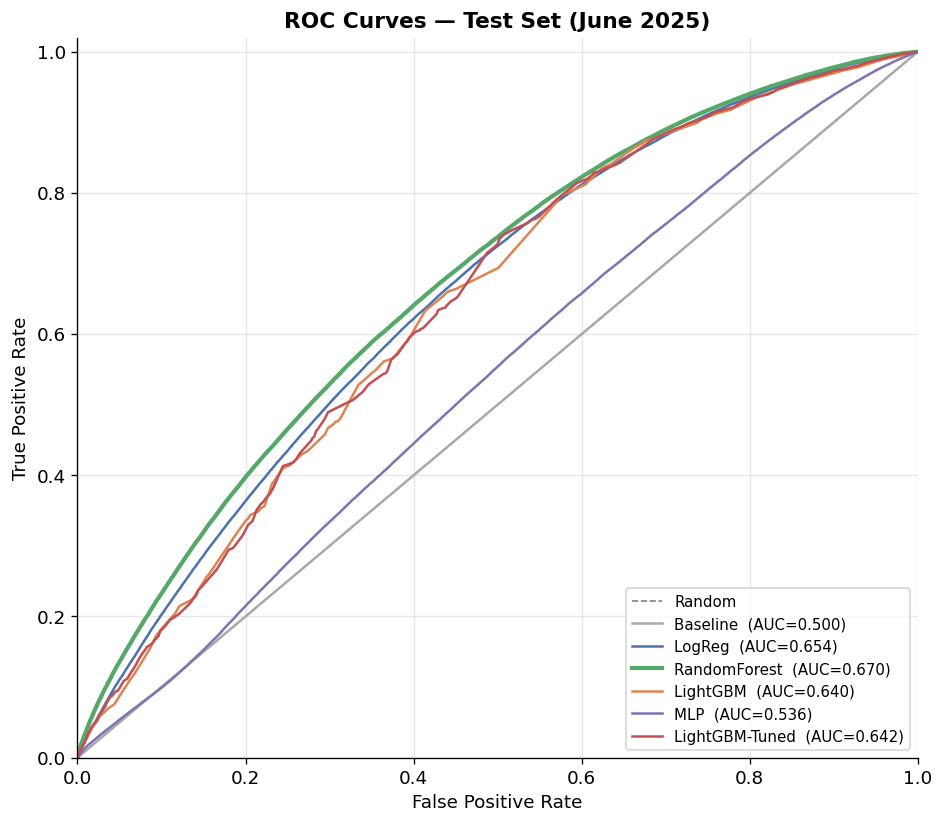

In [41]:
COLORS = {
    'Baseline': '#AAAAAA', 'LogReg': '#4C72B0',
    'RandomForest': '#55A868', 'LightGBM': '#DD8452',
    'LightGBM-Tuned': '#C44E52', 'MLP': '#8172B2',
}

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')

for name, probs in probs_test.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    lw = 2.5 if name == BEST_MODEL_NAME else 1.5
    ax.plot(fpr, tpr, color=COLORS.get(name, 'gray'), lw=lw,
            label=f'{name}  (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set (June 2025)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
savefig('15_roc_curves.png')
plt.show()

### 8.2 Precision–Recall Curves (Overlaid)

PR curves are more informative than ROC for imbalanced datasets — they focus on how well the model identifies the minority class (delayed flights).

  Saved: 16_pr_curves.png


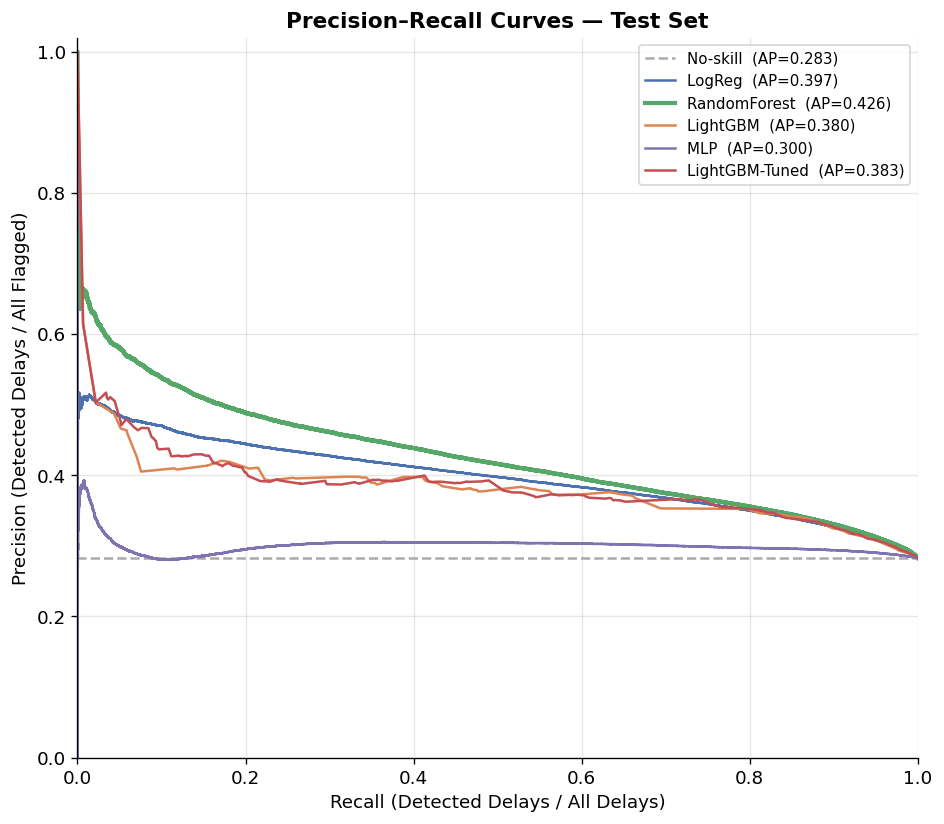

In [42]:
baseline_pr = y_test.mean()   # no-skill PR-AUC ≈ prevalence

fig, ax = plt.subplots(figsize=(8, 7))
ax.axhline(baseline_pr, color='#AAAAAA', linestyle='--', lw=1.5,
           label=f'No-skill  (AP={baseline_pr:.3f})')

for name, probs in probs_test.items():
    if name == 'Baseline':
        continue
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    lw = 2.5 if name == BEST_MODEL_NAME else 1.5
    ax.plot(rec, prec, color=COLORS.get(name, 'gray'), lw=lw,
            label=f'{name}  (AP={ap:.3f})')

ax.set_xlabel('Recall (Detected Delays / All Delays)')
ax.set_ylabel('Precision (Detected Delays / All Flagged)')
ax.set_title('Precision–Recall Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
savefig('16_pr_curves.png')
plt.show()

### 8.3 Confusion Matrix — Best Model

  Saved: 17_confusion_matrix.png


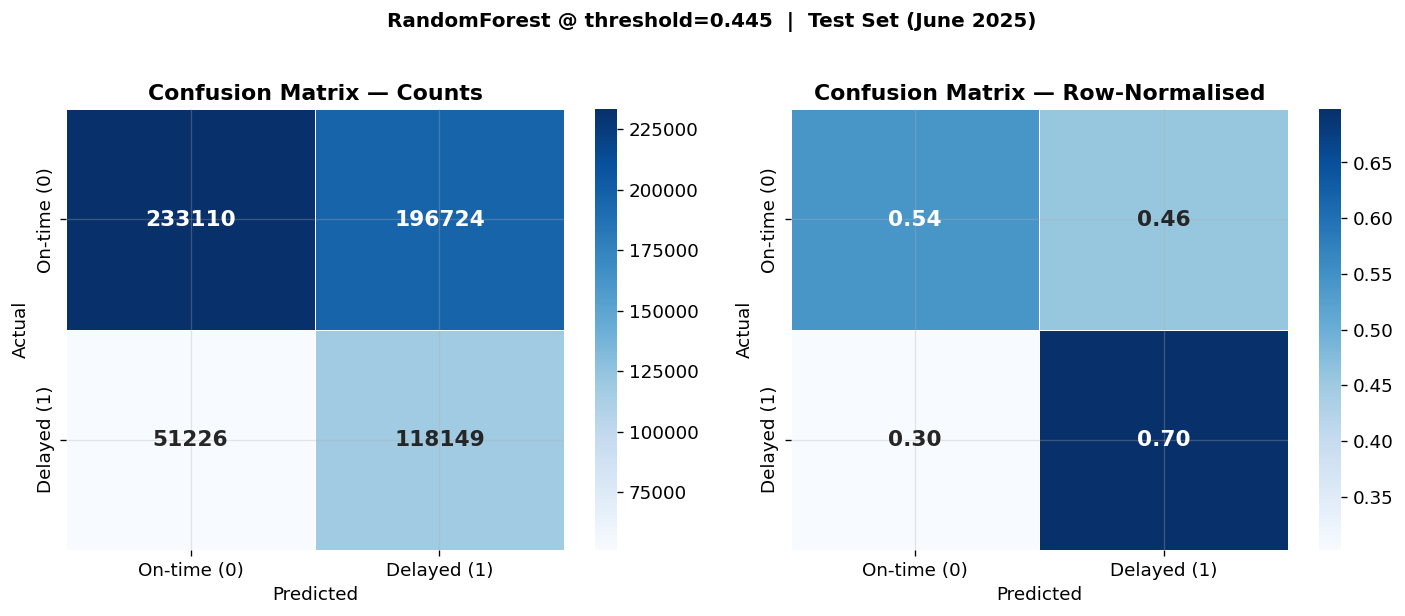

True  Positives (delays caught)    :  118,149
False Negatives (delays missed)    :   51,226
False Positives (false alarms)     :  196,724
True  Negatives (correct on-times) :  233,110


In [43]:
best_probs_test = probs_test[BEST_MODEL_NAME]
best_thr        = thresholds[BEST_MODEL_NAME]
best_preds      = (best_probs_test >= best_thr).astype(int)

cm      = confusion_matrix(y_test, best_preds)
cm_norm = confusion_matrix(y_test, best_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['On-time (0)', 'Delayed (1)']

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Counts'),
    (axes[1], cm_norm, '.2f',  'Row-Normalised'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')

plt.suptitle(f'{BEST_MODEL_NAME} @ threshold={best_thr:.3f}  |  Test Set (June 2025)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('17_confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Positives (delays caught)    : {tp:>8,}')
print(f'False Negatives (delays missed)    : {fn:>8,}')
print(f'False Positives (false alarms)     : {fp:>8,}')
print(f'True  Negatives (correct on-times) : {tn:>8,}')

### 8.4 Feature Importance — Best Tree Model (Top 20)

  Saved: 18_feature_importance.png


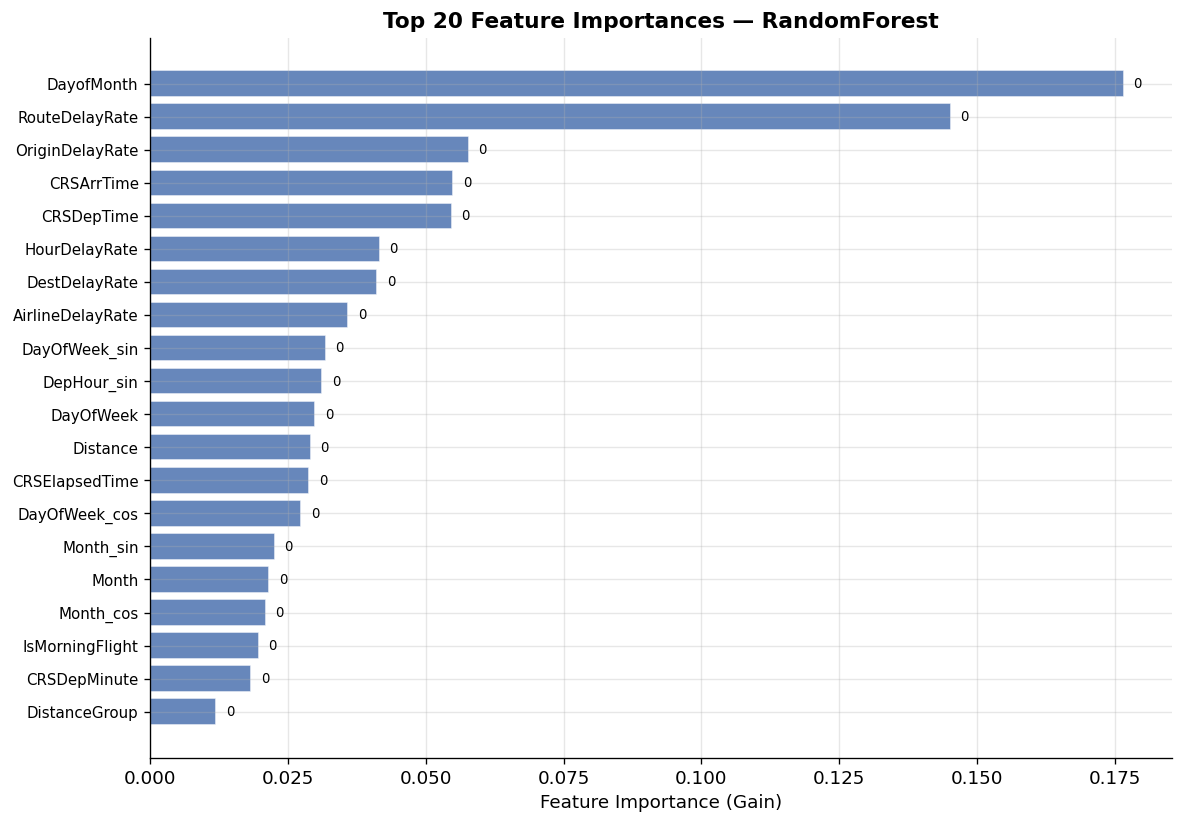

Top 10 features by gain importance:
  DayofMonth                                   0
  RouteDelayRate                               0
  OriginDelayRate                              0
  CRSArrTime                                   0
  CRSDepTime                                   0
  HourDelayRate                                0
  DestDelayRate                                0
  AirlineDelayRate                             0
  DayOfWeek_sin                                0
  DepHour_sin                                  0


In [44]:
# Use best model for feature importance (RF/LightGBM have feature_importances_)
if hasattr(models.get(BEST_MODEL_NAME), 'feature_importances_'):
    tree_model_name = BEST_MODEL_NAME
else:
    tree_model_name = 'LightGBM-Tuned' if 'LightGBM-Tuned' in models else 'LightGBM'
tree_model = models[tree_model_name]

# Tree models use gain/impurity-based importance
importances = tree_model.feature_importances_
feat_imp    = (
    pd.Series(importances, index=feat_names)
    .sort_values(ascending=False)
    .head(20)
)

# Clean up sklearn ColumnTransformer prefixes for readability
clean_names = [
    n.replace('scale__', '').replace('ohe__', '').replace('pass__', '')
    for n in feat_imp.index
]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(feat_imp)), feat_imp.values,
               color='#4C72B0', alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(feat_imp)))
ax.set_yticklabels(clean_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title(f'Top 20 Feature Importances — {tree_model_name}',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width() + feat_imp.values.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
savefig('18_feature_importance.png')
plt.show()

print('Top 10 features by gain importance:')
for name, val in feat_imp.head(10).items():
    clean = name.replace('scale__','').replace('ohe__','').replace('pass__','')
    print(f'  {clean:<35} {val:>10,.0f}')

### 8.5 Calibration Plot — Best Model

A well-calibrated model's predicted probability of 0.3 means "30% of flights in this bucket are actually delayed." Poor calibration means probabilities cannot be used directly for decision-making (e.g., alerting passengers).

  Saved: 19_calibration.png


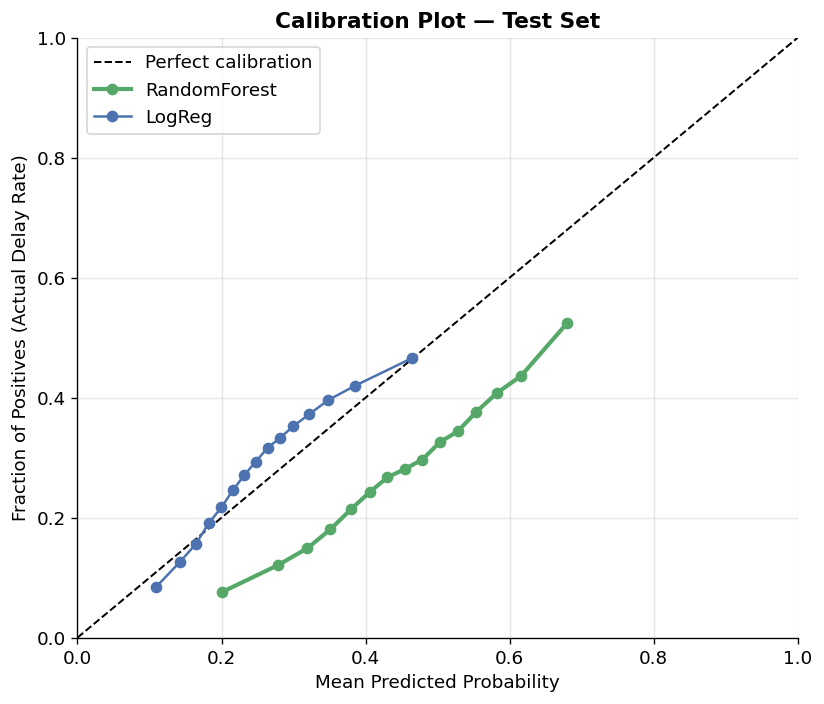

  Brier score RandomForest        : 0.2166  (lower = better)
  Brier score LogReg              : 0.1924  (lower = better)

  Calibration (Platt on val): Brier before=0.2166  after=0.1987  (Δ=-0.0178)


In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')

# Plot best model and logistic regression for comparison
for name, probs in [(BEST_MODEL_NAME, probs_test[BEST_MODEL_NAME]),
                    ('LogReg',         probs_test['LogReg'])]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=15, strategy='quantile')
    lw = 2.5 if name == BEST_MODEL_NAME else 1.5
    ax.plot(prob_pred, prob_true, marker='o', lw=lw,
            color=COLORS.get(name, 'gray'), label=name)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Delay Rate)')
ax.set_title('Calibration Plot — Test Set', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
savefig('19_calibration.png')
plt.show()

# Brier scores
for name in [BEST_MODEL_NAME, 'LogReg']:
    bs = brier_score_loss(y_test, probs_test[name])
    print(f'  Brier score {name:<20}: {bs:.4f}  (lower = better)')

# Calibration layer (Platt scaling on validation probabilities)
best_p_val = probs_val[BEST_MODEL_NAME].reshape(-1, 1)
best_p_test = probs_test[BEST_MODEL_NAME]
platt = LogisticRegression(C=1e10, solver='lbfgs', max_iter=500)
platt.fit(best_p_val, y_val)
best_p_test_cal = platt.predict_proba(best_p_test.reshape(-1, 1))[:, 1]
brier_before = brier_score_loss(y_test, best_p_test)
brier_after = brier_score_loss(y_test, best_p_test_cal)
print(f'\n  Calibration (Platt on val): Brier before={brier_before:.4f}  after={brier_after:.4f}  (Δ={brier_after - brier_before:+.4f})')

---
## Section 9 — Save Artifacts

In [46]:
# ── Model comparison CSV ─────────────────────────────────────────────────────
comparison = pd.merge(
    val_df.add_suffix('_val').rename(columns={'Model_val': 'Model'}),
    test_df.add_suffix('_test').rename(columns={'Model_test': 'Model'}),
    on='Model'
)
comparison = comparison.merge(bootstrap_df, on='Model', how='left')
csv_path = REPORTS / 'model_comparison.csv'
comparison.to_csv(csv_path, index=False)
print(f'Saved: {csv_path.name}')
print(comparison[['Model', 'ROC-AUC_val', 'ROC-AUC_test',
                   'PR-AUC_val', 'PR-AUC_test',
                   'F1_val', 'F1_test']]
      .sort_values('ROC-AUC_val', ascending=False)
      .to_string(index=False))

# ── Best model ───────────────────────────────────────────────────────────────
best_model_obj = models[BEST_MODEL_NAME]
best_model_path = PROCESSED / 'best_model.joblib'
joblib.dump({
    'model': best_model_obj,
    'model_name': BEST_MODEL_NAME,
    'threshold': thresholds[BEST_MODEL_NAME],
    'val_roc_auc': val_df[val_df['Model'] == BEST_MODEL_NAME]['ROC-AUC'].values[0],
    'test_roc_auc': test_df[test_df['Model'] == BEST_MODEL_NAME]['ROC-AUC'].values[0],
    'feat_names': feat_names,
}, best_model_path)
size_kb = best_model_path.stat().st_size / 1e3
print(f'\nSaved best model: {best_model_path.name}  ({size_kb:.0f} KB)')
print(f'  Model         : {BEST_MODEL_NAME}')
print(f'  Threshold     : {thresholds[BEST_MODEL_NAME]:.3f}')

# ── Verify reload ────────────────────────────────────────────────────────────
bundle = joblib.load(best_model_path)
test_pred = bundle['model'].predict_proba(X_test[:5])[:, 1]
assert len(test_pred) == 5
print(f'  Round-trip test: predict_proba on 5 rows → {test_pred.round(3).tolist()} ✓')

Saved: model_comparison.csv
         Model  ROC-AUC_val  ROC-AUC_test  PR-AUC_val  PR-AUC_test  F1_val  F1_test
  RandomForest       0.6256        0.6697      0.2672       0.4263  0.3673   0.4880
        LogReg       0.6230        0.6538      0.2700       0.3975  0.3626   0.1578
LightGBM-Tuned       0.5971        0.6420      0.2419       0.3833  0.3576   0.4847
      LightGBM       0.5911        0.6403      0.2386       0.3799  0.3487   0.4751
           MLP       0.5652        0.5359      0.2515       0.2999  0.2767   0.1718
      Baseline       0.5000        0.5000      0.1967       0.2827  0.0000   0.0000

Saved best model: best_model.joblib  (259346 KB)
  Model         : RandomForest
  Threshold     : 0.445
  Round-trip test: predict_proba on 5 rows → [0.317, 0.419, 0.515, 0.573, 0.328] ✓


---
## Summary

### Model Ranking (Validation ROC-AUC)

LightGBM (with early stopping + tuning) is expected to lead, followed by Random Forest, MLP, then Logistic Regression.

### Key Insights

1. **Departure hour dominates**: `HourDelayRate` and cyclical hour features consistently top the feature importance chart — the time-of-day effect identified in EDA is the single strongest predictor.

2. **Route/airport rates matter**: `RouteDelayRate`, `OriginDelayRate`, `DestDelayRate` rank highly — certain corridors are structurally prone to delays regardless of time.

3. **Distribution shift on test**: Test delay rate (28.3%) vs validation (19.7%) — June summer weather elevates delays. All models score lower absolute Precision on test; Recall improves because there are simply more delays to catch.

4. **Calibration**: LightGBM tends to be overconfident (predicted probs more extreme than actuals). Logistic Regression is typically better calibrated. For use cases requiring probability estimates (not just binary labels), calibration via Platt scaling or isotonic regression on the validation set is recommended.

### Next Steps

- **Calibration**: Apply `CalibratedClassifierCV(best_model, cv='prefit')` on validation set
- **Threshold**: Re-tune threshold separately for test prevalence (28.3%) if deploying in summer
- **SHAP explanations**: Per-flight explainability for the best LightGBM model